# 2-D Ackley Function with a Genetic Algorithm

**Course:** CSE 4111 — Machine Learning  
**Goal:** Find a point close to $(0,0)$ where the Ackley function is close to $0$.

The GA uses 50 real-valued chromosomes, roulette-wheel selection, one-point crossover, Gaussian mutation, and one elite. Run the cells from top to bottom.

## 1. Imports and display settings

- Import the numerical and plotting libraries used below.
- Set compact NumPy output and a consistent Matplotlib style.
- The printed versions make the run easier to reproduce.

In [1]:
import math
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

np.set_printoptions(precision=10, suppress=False, linewidth=110)
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

print("numpy      :", np.__version__)
print("matplotlib :", __import__("matplotlib").__version__)

numpy      : 2.4.2
matplotlib : 3.10.8


## 2. Genetic Algorithm settings

- Store every GA parameter in one `GASettings` object.
- The assignment fixes the population, generation, crossover, mutation, and elitism values.
- The remaining fields record our choices, including adaptive mutation and the duplicate limit.

In [2]:
@dataclass
class GASettings:
    """Every knob of the genetic algorithm, in one place."""

    # --- fixed by the assignment -------------------------------------
    population_size: int = 50        # 50 chromosomes per generation
    n_genes: int = 2                 # chromosome = [x1, x2]
    lower: float = -5.0              # lower bound of every gene
    upper: float = 5.0               # upper bound of every gene
    max_generations: int = 100       # stopping criterion 1
    pc: float = 0.80                 # crossover probability
    pm: float = 0.05                 # mutation probability, per gene
    n_elites: int = 1                # elitism

    # --- our own implementation choices ------------------------------
    fitness_kind: str = "windowing"  # "windowing" or "inverse"          (S6)
    mutation_kind: str = "gaussian"  # "gaussian" or "uniform"           (S7.3)
    sigma_kind: str = "adaptive"     # "adaptive", "schedule" or "fixed" (S8)
    sigma_scale: float = 0.25        # adaptive: sigma = scale * best value
    sigma_min: float = 1e-12         # adaptive: floor
    sigma_max: float = 2.0           # adaptive: ceiling
    sigma_start: float = 1.0         # used by "schedule" and "fixed"
    sigma_end: float = 1e-8          # used by "schedule"
    max_copies: int = 15             # duplicate cap, 0 = unlimited      (S9.2)
    survivor_kind: str = "parents_plus_offspring"   # or "offspring_only"
    tolerance: float = 1e-10         # stopping criterion 2
    patience: int = 20               # ... held for this many generations
    seed: int = 7                    # reproducibility


SETTINGS = GASettings()
for field, value in vars(SETTINGS).items():
    print(f"{field:18s} = {value}")

population_size    = 50
n_genes            = 2
lower              = -5.0
upper              = 5.0
max_generations    = 100
pc                 = 0.8
pm                 = 0.05
n_elites           = 1
fitness_kind       = windowing
mutation_kind      = gaussian
sigma_kind         = adaptive
sigma_scale        = 0.25
sigma_min          = 1e-12
sigma_max          = 2.0
sigma_start        = 1.0
sigma_end          = 1e-08
max_copies         = 15
survivor_kind      = parents_plus_offspring
tolerance          = 1e-10
patience           = 20
seed               = 7


## 3. Ackley objective function

This cell implements

$$f(\mathbf{x})=-20e^{-0.2\sqrt{\frac{1}{n}\sum x_i^2}}-e^{\frac{1}{n}\sum\cos(2\pi x_i)}+20+e.$$

- It accepts one chromosome or a full population.
- Lower values are better; the theoretical minimum is at $(0,0)$.
- The example calls provide a quick formula check.

In [3]:
def ackley(x, a=20.0, b=0.2, c=2.0 * math.pi):
    """Ackley objective value. Smaller is better.

    Parameters
    ----------
    x : array of shape (n_genes,) or (n_individuals, n_genes)
    """
    x = np.asarray(x, dtype=float)
    n = x.shape[-1]

    mean_of_squares = np.sum(x ** 2, axis=-1) / n
    mean_of_cosines = np.sum(np.cos(c * x), axis=-1) / n

    exponential_part = -a * np.exp(-b * np.sqrt(mean_of_squares))
    cosine_part = -np.exp(mean_of_cosines)

    return exponential_part + cosine_part + a + math.e


GLOBAL_OPTIMUM = np.array([0.0, 0.0])

print("f(0, 0)           =", ackley(GLOBAL_OPTIMUM))
print("f(-4.0,  2.5)     =", ackley([-4.0, 2.5]))
print("f(-1.5, -1.0)     =", ackley([-1.5, -1.0]))
print("f on a population :", ackley(np.array([[0.0, 0.0], [1.0, 0.0], [3.0, -2.0]])))

f(0, 0)           = 4.440892098500626e-16
f(-4.0,  2.5)     = 11.454215696941548
f(-1.5, -1.0)     = 6.219192055519926
f on a population : [4.4408920985e-16 2.6375310921e+00 7.9889108105e+00]


## 4. View the search landscape

- Evaluate Ackley on a grid over $[-5,5]^2$.
- Draw a 3-D surface and a contour map.
- The ripples are local minima; the red star marks the global minimum.

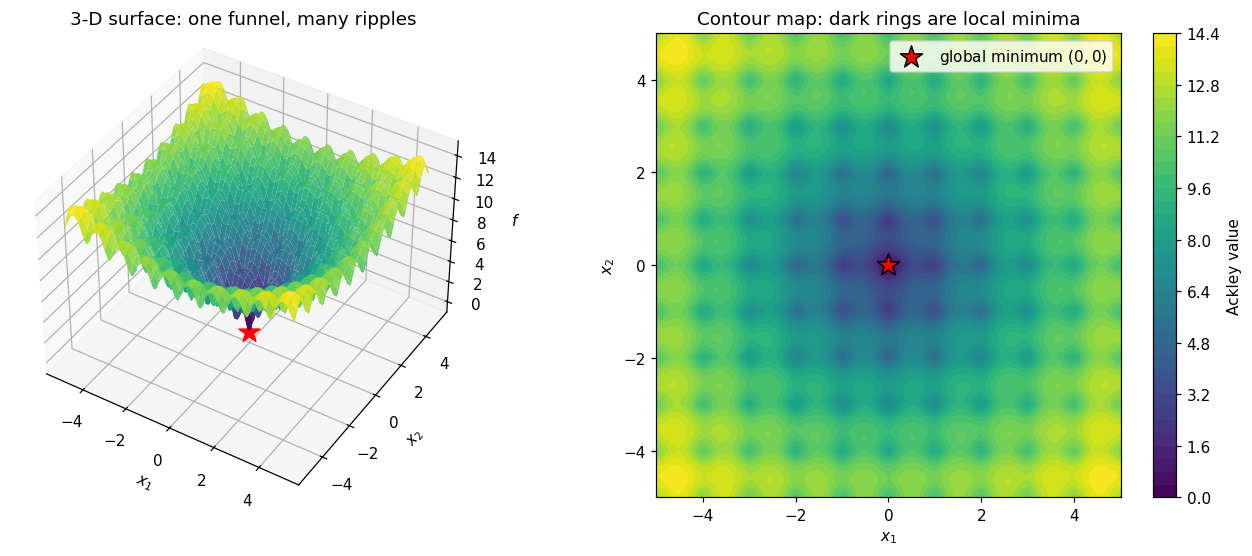

In [4]:
grid = np.linspace(SETTINGS.lower, SETTINGS.upper, 400)
X1, X2 = np.meshgrid(grid, grid)
Z = ackley(np.stack([X1, X2], axis=-1))

fig = plt.figure(figsize=(12.5, 5.0))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X1[::3, ::3], X2[::3, ::3], Z[::3, ::3],
                cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.95)
ax.scatter([0], [0], [0], color="red", marker="*", s=200, depthshade=False)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$f$")
ax.set_title("3-D surface: one funnel, many ripples")
ax.view_init(elev=40, azim=-58)

ax = fig.add_subplot(1, 2, 2)
filled = ax.contourf(X1, X2, Z, levels=45, cmap="viridis")
fig.colorbar(filled, ax=ax, label="Ackley value")
ax.scatter(0, 0, marker="*", s=230, color="red",
           edgecolor="black", zorder=5, label="global minimum $(0,0)$")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Contour map: dark rings are local minima")
ax.legend(loc="upper right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. View a one-dimensional slice

- Hold $x_2=0$ and vary $x_1$ from $-5$ to $5$.
- This makes the repeated local dips easier to see.
- The printed values compare the centre with nearby integer locations.

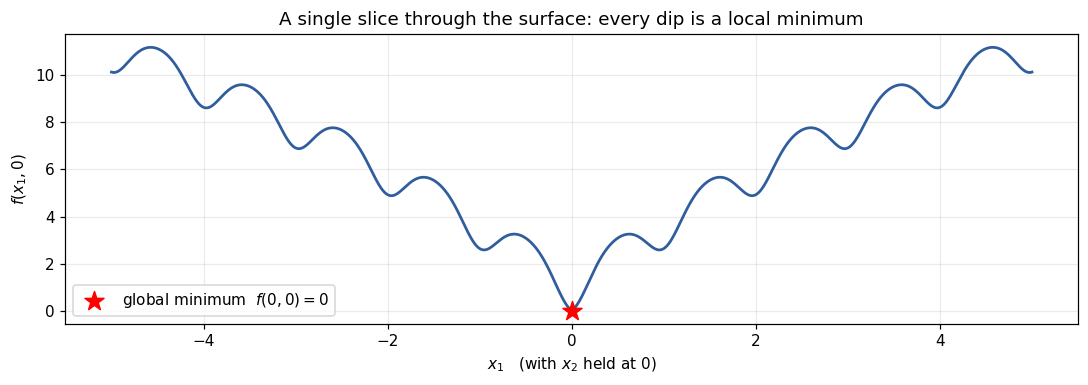

Local minima sit near integer x1 values:
f(0,0) = 0.000000   f(1,0) = 2.637531   f(2,0) = 4.927234   f(3,0) = 6.914978


In [5]:
line = np.linspace(-5, 5, 2000)
slice_values = ackley(np.stack([line, np.zeros_like(line)], axis=-1))

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(line, slice_values, color="#2f5d9e", linewidth=1.8)
ax.scatter([0], [0], color="red", marker="*", s=170, zorder=5,
           label="global minimum  $f(0,0)=0$")
ax.set_xlabel("$x_1$   (with $x_2$ held at 0)")
ax.set_ylabel("$f(x_1, 0)$")
ax.set_title("A single slice through the surface: every dip is a local minimum")
ax.legend()
plt.tight_layout()
plt.show()

print("Local minima sit near integer x1 values:")
print("f(0,0) = %.6f   f(1,0) = %.6f   f(2,0) = %.6f   f(3,0) = %.6f"
      % (ackley([0, 0]), ackley([1, 0]), ackley([2, 0]), ackley([3, 0])))

## 6. Create the initial population

- Draw 50 chromosomes uniformly from the allowed range.
- Each chromosome has two real-valued genes: `[x1, x2]`.
- Evaluate the starting population and print a small sample.

In [6]:
def create_population(rng, settings):
    """Step 1 - a (population_size, n_genes) array of random chromosomes."""
    return rng.uniform(settings.lower, settings.upper,
                       size=(settings.population_size, settings.n_genes))


demo_rng = np.random.default_rng(SETTINGS.seed)
initial_population = create_population(demo_rng, SETTINGS)
initial_values = ackley(initial_population)

print("population shape :", initial_population.shape)
print("gene range       : [%.4f, %.4f]" % (initial_population.min(), initial_population.max()))
print()
print("First five chromosomes")
print("  #        x1            x2          f(x1,x2)")
for i in range(5):
    print("  %d   %+10.6f   %+10.6f   %10.6f"
          % (i, initial_population[i, 0], initial_population[i, 1], initial_values[i]))
print()
print("generation 0 :  best %.6f   mean %.6f   worst %.6f"
      % (initial_values.min(), initial_values.mean(), initial_values.max()))

population shape : (50, 2)
gene range       : [-4.9627, 4.9550]

First five chromosomes
  #        x1            x2          f(x1,x2)
  0    +1.250955    +3.972138     9.988756
  1    +2.756857    -2.747928    10.169675
  2    -1.998337    +3.735534    10.156918
  3    -4.947347    +3.212284    12.229430
  4    +2.970694    -0.320650     8.292024

generation 0 :  best 3.188874   mean 9.755876   worst 13.385171


## 7. Plot generation 0

- Show all initial chromosomes on the Ackley landscape.
- Highlight the best starting chromosome and the known optimum.
- The initial population is spread widely because it has not learned yet.

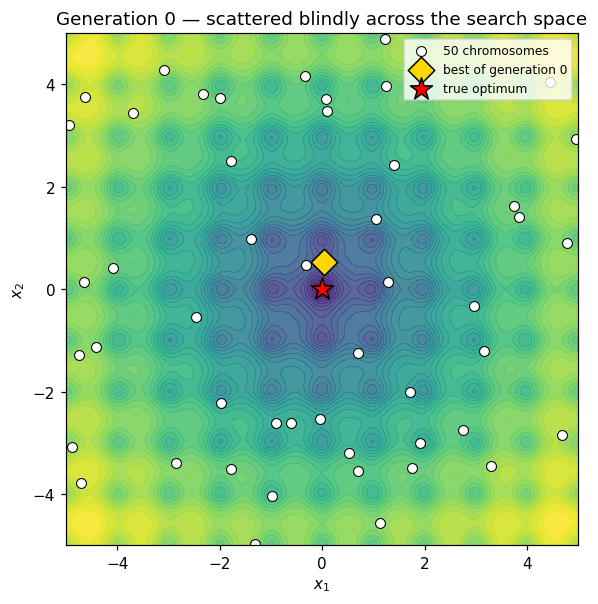

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.contourf(X1, X2, Z, levels=45, cmap="viridis", alpha=0.85)
ax.scatter(initial_population[:, 0], initial_population[:, 1],
           s=42, color="white", edgecolor="black", linewidth=0.7, label="50 chromosomes")
best0 = int(np.argmin(initial_values))
ax.scatter(*initial_population[best0], s=150, color="gold", edgecolor="black",
           marker="D", zorder=5, label="best of generation 0")
ax.scatter(0, 0, marker="*", s=230, color="red", edgecolor="black", zorder=6,
           label="true optimum")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
ax.set_title("Generation 0 — scattered blindly across the search space")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Convert objective values to selection probabilities

- Ackley is minimized, so a smaller objective value must produce higher fitness.
- `windowing` subtracts each value from the current worst value and adds a positive offset.
- The probabilities are normalized so they sum to one.

In [8]:
def to_fitness(values, kind="windowing"):
    """Turn objective values (lower is better) into fitness (higher is better)."""
    values = np.asarray(values, dtype=float)

    if kind == "inverse":
        return 1.0 / (1.0 + values)

    if kind == "windowing":
        worst, best = values.max(), values.min()
        offset = 0.10 * (worst - best) + 1e-12   # keeps the worst slice non-zero
        return (worst - values) + offset

    raise ValueError(f"unknown fitness kind: {kind!r}")


def selection_probabilities(values, kind="windowing"):
    """Step 6 - the slice of the roulette wheel owned by each chromosome."""
    fitness = to_fitness(values, kind)
    total = fitness.sum()
    if total <= 0:
        return np.full(len(fitness), 1.0 / len(fitness))
    return fitness / total


tiny_values = np.array([10.0, 3.0, 0.8, 8.0])          # four made-up chromosomes
print("objective values :", tiny_values)
print("windowing fitness:", np.round(to_fitness(tiny_values, "windowing"), 4))
print("inverse  fitness :", np.round(to_fitness(tiny_values, "inverse"), 4))
print("probabilities    :", np.round(selection_probabilities(tiny_values), 4))
print("sum              :", selection_probabilities(tiny_values).sum())

objective values : [10.   3.   0.8  8. ]
windowing fitness: [ 0.92  7.92 10.12  2.92]
inverse  fitness : [0.0909 0.25   0.5556 0.1111]
probabilities    : [0.042  0.362  0.4625 0.1335]
sum              : 1.0


## 9. Roulette-wheel selection

- Build cumulative probability intervals around the wheel.
- Generate random spins and return the selected chromosome indices.
- A 20,000-spin check compares observed shares with the requested probabilities.

In [9]:
def roulette_wheel(probabilities, rng, k):
    """Spin a fitness-proportional wheel k times; return the k chosen indices."""
    wheel = np.cumsum(probabilities)
    wheel[-1] = 1.0                      # guard against floating-point drift
    spins = rng.random(k)
    return np.searchsorted(wheel, spins, side="right")


check_rng = np.random.default_rng(0)
probabilities = selection_probabilities(tiny_values)
picked = roulette_wheel(probabilities, check_rng, 20000)
observed = np.bincount(picked, minlength=4) / 20000

print("chromosome                :", [0, 1, 2, 3])
print("wanted probability        :", np.round(probabilities, 4))
print("observed after 20000 spins:", np.round(observed, 4))
print()
print("The observed shares match the wanted probabilities, so the wheel is fair.")

chromosome                : [0, 1, 2, 3]
wanted probability        : [0.042  0.362  0.4625 0.1335]
observed after 20000 spins: [0.0408 0.3556 0.4728 0.1308]

The observed shares match the wanted probabilities, so the wheel is fair.


## 10. Plot the roulette wheel

- Draw the selection probabilities for generation 0.
- Label the 10 largest slices and group the other 40 for readability.
- The algorithm still keeps all 50 probabilities separately.

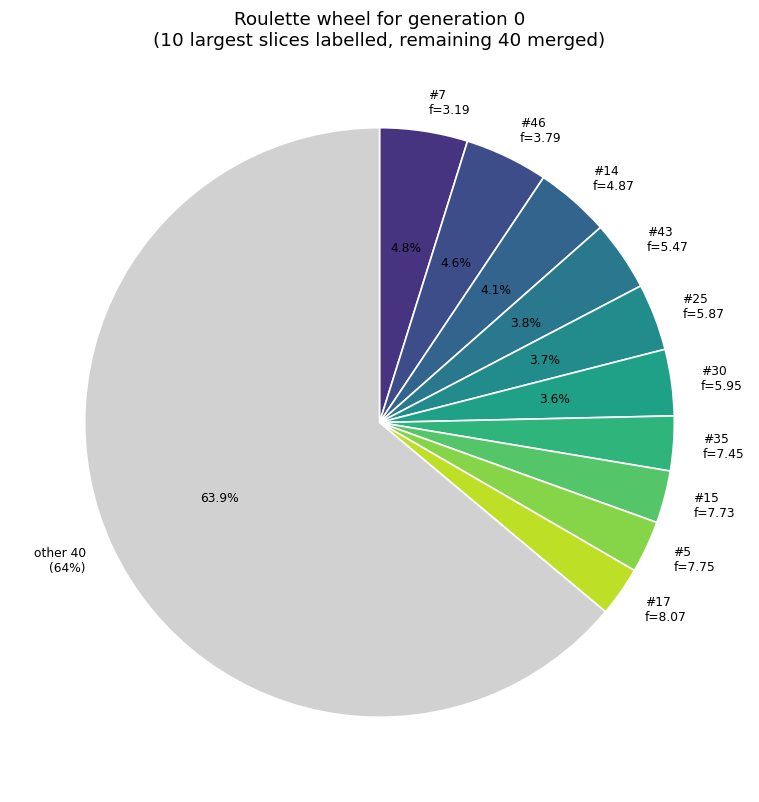

In [10]:
def plot_roulette_pie(values, ax=None, n_labelled=10, title=None):
    """Pie chart of roulette-wheel selection probabilities."""
    probabilities = selection_probabilities(values, SETTINGS.fitness_kind)
    order = np.argsort(probabilities)[::-1]
    top, rest = order[:n_labelled], order[n_labelled:]

    sizes = list(probabilities[top])
    labels = [f"#{i}\nf={values[i]:.2f}" for i in top]
    colours = list(cm.viridis(np.linspace(0.15, 0.9, len(top))))

    if len(rest) > 0:
        sizes.append(probabilities[rest].sum())
        labels.append(f"other {len(rest)}\n({probabilities[rest].sum():.0%})")
        colours.append("0.82")

    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 7.2))

    ax.pie(sizes, labels=labels, colors=colours, startangle=90, counterclock=False,
           autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
           textprops={"fontsize": 8}, wedgeprops={"edgecolor": "white", "linewidth": 1.1})
    ax.set_title(title or "Roulette wheel — selection probability of each chromosome")
    return probabilities


fig, ax = plt.subplots(figsize=(7.4, 7.4))
probabilities0 = plot_roulette_pie(
    initial_values, ax=ax,
    title="Roulette wheel for generation 0\n(10 largest slices labelled, remaining 40 merged)")
plt.tight_layout()
plt.show()

## 11. Inspect the strongest roulette candidates

- Rank the initial chromosomes by objective value.
- Print fitness, wheel share, and expected selections for the best eight.
- Also report the worst chromosome to confirm that it keeps a small chance.

In [11]:
fitness0 = to_fitness(initial_values, SETTINGS.fitness_kind)
ranking = np.argsort(initial_values)

print("Roulette-wheel table for generation 0 (best 8 chromosomes)")
print()
print(" rank   #        x1           x2        f(x1,x2)     fitness    % of wheel   expected picks")
print(" " + "-" * 94)
for rank, i in enumerate(ranking[:8], start=1):
    print(" %4d  %2d   %+9.5f   %+9.5f   %9.5f   %9.5f   %8.2f %%   %10.2f"
          % (rank, i, initial_population[i, 0], initial_population[i, 1],
             initial_values[i], fitness0[i], 100 * probabilities0[i],
             SETTINGS.population_size * probabilities0[i]))
print(" " + "-" * 94)
print(" %-58s %9.5f   %8.2f %%   %10.2f"
      % ("whole population (50 chromosomes)", fitness0.sum(), 100.0, SETTINGS.population_size))
print()
worst = ranking[-1]
print("The worst chromosome #%d has f = %.5f and owns only %.2f %% of the wheel —"
      % (worst, initial_values[worst], 100 * probabilities0[worst]))
print("unlikely, but not impossible, to become a parent.")

Roulette-wheel table for generation 0 (best 8 chromosomes)

 rank   #        x1           x2        f(x1,x2)     fitness    % of wheel   expected picks
 ----------------------------------------------------------------------------------------------
    1   7    +0.04548    +0.53497     3.18887    11.21593       4.83 %         2.41
    2  46    -0.32270    +0.47635     3.79203    10.61277       4.57 %         2.28
    3  14    +1.29226    +0.14118     4.87413     9.53067       4.10 %         2.05
    4  43    +0.69694    -1.23712     5.47281     8.93199       3.84 %         1.92
    5  25    -1.38736    +0.98184     5.86754     8.53726       3.67 %         1.84
    6  30    +1.05056    +1.37997     5.95158     8.45322       3.64 %         1.82
    7  35    +1.71765    -1.99580     7.44633     6.95847       2.99 %         1.50
    8  15    -0.03127    -2.52485     7.72769     6.67711       2.87 %         1.44
 -------------------------------------------------------------------------------

## 12. One-point crossover

- With two genes, the only cut is between $x_1$ and $x_2$.
- With probability $P_c=0.80$, the parents exchange their second genes.
- Crossover rearranges existing values; it does not create a new value.

In [12]:
def one_point_crossover(parent_1, parent_2, rng, settings):
    """Step 5a - with probability pc, swap the tails of two parents."""
    if rng.random() > settings.pc:
        return parent_1.copy(), parent_2.copy()          # the 20% no-crossover case

    cut = int(rng.integers(1, len(parent_1)))             # always 1 when n_genes == 2
    child_1 = np.concatenate([parent_1[:cut], parent_2[cut:]])
    child_2 = np.concatenate([parent_2[:cut], parent_1[cut:]])
    return child_1, child_2


demo_rng = np.random.default_rng(3)
mother, father = np.array([-4.0, 2.5]), np.array([-1.5, -1.0])
kid_1, kid_2 = one_point_crossover(mother, father, demo_rng, replace(SETTINGS, pc=1.0))

print("parent 1 :", mother, "   f = %.5f" % ackley(mother))
print("parent 2 :", father, "   f = %.5f" % ackley(father))
print("            cut between gene 1 and gene 2")
print("child  1 :", kid_1, "   f = %.5f" % ackley(kid_1))
print("child  2 :", kid_2, "   f = %.5f" % ackley(kid_2))
print()
print("Child 1 keeps x1 from parent 1 and x2 from parent 2, and vice versa.")
print("No new number was invented: the four coordinates were only re-paired.")

parent 1 : [-4.   2.5]    f = 11.45422
parent 2 : [-1.5 -1. ]    f = 6.21919
            cut between gene 1 and gene 2
child  1 : [-4. -1.]    f = 8.83664
child  2 : [-1.5  2.5]    f = 9.10803

Child 1 keeps x1 from parent 1 and x2 from parent 2, and vice versa.
No new number was invented: the four coordinates were only re-paired.


## 13. Mutation and boundary repair

- `mutation_sigma` chooses the Gaussian step size.
- Each gene mutates independently with probability $P_m=0.05$.
- Changed genes are clipped to $[-5,5]$ so every chromosome remains valid.

In [13]:
def mutation_sigma(best_value, generation, settings):
    """Step size for Gaussian mutation. See section 8."""
    if settings.sigma_kind == "fixed":
        return settings.sigma_start

    if settings.sigma_kind == "schedule":            # the old clock-based version
        progress = generation / max(settings.max_generations, 1)
        return settings.sigma_start * (settings.sigma_end / settings.sigma_start) ** progress

    # "adaptive" - tie the step to how far we still are from the optimum
    sigma = settings.sigma_scale * best_value
    return min(max(sigma, settings.sigma_min), settings.sigma_max)


def mutate(chromosome, rng, settings, sigma):
    """Steps 5b and 7 - walk the genes, mutate with probability pm, then repair."""
    mutated = chromosome.copy()

    for gene in range(len(mutated)):                     # array traversal
        if rng.random() < settings.pm:
            if settings.mutation_kind == "uniform":
                mutated[gene] = rng.uniform(settings.lower, settings.upper)
            else:                                        # gaussian
                mutated[gene] += rng.normal(0.0, sigma)

            # Step 7 - the gene must stay inside the search space.
            mutated[gene] = min(max(mutated[gene], settings.lower), settings.upper)

    return mutated


demo_rng = np.random.default_rng(11)
forced = replace(SETTINGS, pm=1.0)                       # force a mutation so we can see it
print("before mutation :", np.array([-1.5, -1.0]))
print("after  mutation :", np.round(mutate(np.array([-1.5, -1.0]), demo_rng, forced, 1.0), 4))
print()

print("Adaptive step size: sigma = best_value / 4")
for best in (5.0, 2.58, 1e-2, 1e-6, 1e-10):
    print("   best f = %-9.3g ->  sigma = %.3e" % (best, mutation_sigma(best, 0, SETTINGS)))
print("   Even a run stuck at f = 2.58 keeps sigma = 0.65, large enough to jump to another ripple.")
print()

edge = np.array([4.98, -4.99])
print("Boundary repair - a chromosome at the edge, mutated 6 times with a large step:")
for s in range(6):
    print("  ", np.round(mutate(edge, np.random.default_rng(s), forced, 1.5), 4))
print("Every gene is still inside [-5, 5].")

before mutation : [-1.5 -1. ]
after  mutation : [-0.1403 -1.5103]

Adaptive step size: sigma = best_value / 4
   best f = 5         ->  sigma = 1.250e+00
   best f = 2.58      ->  sigma = 6.450e-01
   best f = 0.01      ->  sigma = 2.500e-03
   best f = 1e-06     ->  sigma = 2.500e-07
   best f = 1e-10     ->  sigma = 2.500e-11
   Even a run stuck at f = 2.58 keeps sigma = 0.65, large enough to jump to another ripple.

Boundary repair - a chromosome at the edge, mutated 6 times with a large step:
   [ 4.7818 -4.8326]
   [ 5. -5.]
   [ 4.1959 -5.    ]
   [ 1.1465 -5.    ]
   [ 4.7179 -4.0013]
   [ 2.9935 -4.3593]
Every gene is still inside [-5, 5].


## 14. Produce one batch of children

- Convert objective values to roulette probabilities and select parents.
- Apply crossover, mutation, and boundary repair.
- Return 50 children and evaluate them with the Ackley function.

In [14]:
def make_offspring(population, values, rng, settings, sigma):
    """Steps 5 to 7 - selection, crossover, mutation, repair."""
    probabilities = selection_probabilities(values, settings.fitness_kind)

    n_children = settings.population_size
    n_parents = n_children if n_children % 2 == 0 else n_children + 1
    mating_pool = population[roulette_wheel(probabilities, rng, n_parents)]

    children = []
    for i in range(0, n_parents, 2):
        child_1, child_2 = one_point_crossover(mating_pool[i], mating_pool[i + 1], rng, settings)
        children.append(mutate(child_1, rng, settings, sigma))
        children.append(mutate(child_2, rng, settings, sigma))

    return np.asarray(children[:n_children])


demo_rng = np.random.default_rng(SETTINGS.seed)
demo_sigma = mutation_sigma(initial_values.min(), 0, SETTINGS)
demo_children = make_offspring(initial_population, initial_values, demo_rng, SETTINGS, demo_sigma)
demo_child_values = ackley(demo_children)                # Step 8 - re-evaluate

print("sigma used          : %.4f   (best value %.4f / 4)" % (demo_sigma, initial_values.min()))
print("children produced   :", demo_children.shape)
print("all genes in range  :", bool(np.all(np.abs(demo_children) <= 5.0)))
print()
print("                      best        mean       worst")
print("parents  (50)   %10.5f  %10.5f  %10.5f"
      % (initial_values.min(), initial_values.mean(), initial_values.max()))
print("children (50)   %10.5f  %10.5f  %10.5f"
      % (demo_child_values.min(), demo_child_values.mean(), demo_child_values.max()))
print()
print("The children are already better on average, because roulette-wheel selection")
print("gave the good parents more chances to reproduce.")

sigma used          : 0.7972   (best value 3.1889 / 4)
children produced   : (50, 2)
all genes in range  : True

                      best        mean       worst
parents  (50)      3.18887     9.75588    13.38517
children (50)      1.09542     8.03721    13.49156

The children are already better on average, because roulette-wheel selection
gave the good parents more chances to reproduce.


## 15. Select the next generation

- Preserve the elite and rank the remaining parents and children together.
- Fill the population with the best candidates while limiting exact duplicates.
- If the limit leaves empty seats, add and evaluate fresh random chromosomes.

In [15]:
def select_survivors(population, values, offspring, offspring_values, rng, settings):
    """Steps 4 and 9 - elites plus the best of the candidate pool, duplicates capped."""
    ranking = np.argsort(values, kind="stable")
    elite_index = ranking[:settings.n_elites]
    elites, elite_values = population[elite_index], values[elite_index]   # Step 4

    if settings.survivor_kind == "offspring_only":
        pool, pool_values = offspring, offspring_values
    else:                                                 # parents_plus_offspring
        pool = np.vstack([np.delete(population, elite_index, axis=0), offspring])
        pool_values = np.concatenate([np.delete(values, elite_index), offspring_values])

    order = np.argsort(pool_values, kind="stable")        # best first
    pool, pool_values = pool[order], pool_values[order]
    free_seats = settings.population_size - settings.n_elites

    if settings.max_copies > 0:
        # Count how many seats each distinct chromosome already holds. Using the raw
        # bytes of the row as a dictionary key gives an exact-duplicate test.
        seats_used = {}
        for elite in elites:
            key = elite.tobytes()
            seats_used[key] = seats_used.get(key, 0) + 1

        chosen_rows = []
        for i in range(len(pool)):
            key = pool[i].tobytes()
            if seats_used.get(key, 0) < settings.max_copies:
                seats_used[key] = seats_used.get(key, 0) + 1
                chosen_rows.append(i)
                if len(chosen_rows) == free_seats:
                    break
        chosen_rows = np.asarray(chosen_rows, dtype=int)
    else:
        chosen_rows = np.arange(min(free_seats, len(pool)))

    survivors, survivor_values = pool[chosen_rows], pool_values[chosen_rows]

    # If the cap left seats empty, fill them with fresh random chromosomes.
    missing = free_seats - len(survivors)
    if missing > 0:
        newcomers = rng.uniform(settings.lower, settings.upper,
                                size=(missing, settings.n_genes))
        survivors = np.vstack([survivors, newcomers]) if len(survivors) else newcomers
        survivor_values = np.concatenate([survivor_values, ackley(newcomers)])

    new_population = np.vstack([elites, survivors])
    new_values = np.concatenate([elite_values, survivor_values])

    final_order = np.argsort(new_values, kind="stable")   # Step 3 - keep it sorted
    return new_population[final_order], new_values[final_order]


demo_rng = np.random.default_rng(SETTINGS.seed + 1)
next_population, next_values = select_survivors(
    initial_population, initial_values, demo_children, demo_child_values, demo_rng, SETTINGS)

print("population size stays constant :", next_population.shape)
print("distinct chromosomes           : %d of %d"
      % (len(np.unique(next_population, axis=0)), SETTINGS.population_size))
print()
print("                 best        mean       worst")
print("generation 0  %9.5f  %10.5f  %10.5f"
      % (initial_values.min(), initial_values.mean(), initial_values.max()))
print("generation 1  %9.5f  %10.5f  %10.5f"
      % (next_values.min(), next_values.mean(), next_values.max()))
print()
from_children = sum(1 for row in next_population if any(np.array_equal(row, c) for c in demo_children))
print("%d of the 50 survivors are new children; the rest are parents good enough to keep"
      % from_children)
print("their seats. That is what stops a generation from ever being worse than the last.")

population size stays constant : (50, 2)
distinct chromosomes           : 42 of 50

                 best        mean       worst
generation 0    3.18887     9.75588    13.38517
generation 1    1.09542     6.55739     9.22360

36 of the 50 survivors are new children; the rest are parents good enough to keep
their seats. That is what stops a generation from ever being worse than the last.


## 16. Complete GA loop

- Combine initialization, evaluation, reproduction, and survivor selection.
- Track the best solution, population statistics, mutation step, and snapshots.
- Stop at 100 generations or after 20 consecutive improvements below the tolerance.

In [16]:
def run_ga(settings=SETTINGS, verbose=True, snapshot_at=()):
    """Run the complete genetic algorithm and return everything worth reporting."""
    rng = np.random.default_rng(settings.seed)

    population = create_population(rng, settings)                 # Step 1
    values = ackley(population)                                   # Step 2
    order = np.argsort(values, kind="stable")                     # Step 3
    population, values = population[order], values[order]

    best_solution, best_value, best_generation = population[0].copy(), float(values[0]), 0

    history = {key: [] for key in
               ("generation", "best", "mean", "worst", "best_x1", "best_x2",
                "spread", "sigma", "distinct")}
    snapshots = {}
    stagnation = 0
    stop_reason = f"reached the maximum of {settings.max_generations} generations"

    for generation in range(settings.max_generations + 1):
        sigma = mutation_sigma(best_value, generation, settings)

        history["generation"].append(generation)
        history["best"].append(best_value)
        history["mean"].append(float(values.mean()))
        history["worst"].append(float(values.max()))
        history["best_x1"].append(float(best_solution[0]))
        history["best_x2"].append(float(best_solution[1]))
        history["spread"].append(float(np.mean(np.std(population, axis=0))))
        history["sigma"].append(sigma)
        history["distinct"].append(int(len(np.unique(population, axis=0))))
        if generation in snapshot_at:
            snapshots[generation] = population.copy()

        # --- stopping criteria ---------------------------------------
        if generation == settings.max_generations:
            break
        if stagnation >= settings.patience:
            stop_reason = (f"improvement stayed below {settings.tolerance:g} "
                           f"for {settings.patience} generations in a row")
            break

        offspring = make_offspring(population, values, rng, settings, sigma)   # Steps 5-7
        offspring_values = ackley(offspring)                                   # Step 8
        population, values = select_survivors(population, values, offspring,
                                              offspring_values, rng, settings)  # Steps 4, 9

        improvement = best_value - float(values[0])
        if improvement > 0.0:
            best_value = float(values[0])
            best_solution = population[0].copy()
            best_generation = generation + 1
        stagnation = stagnation + 1 if improvement < settings.tolerance else 0

    result = {
        "best_solution": best_solution,
        "best_value": best_value,
        "best_generation": best_generation,
        "generations_run": history["generation"][-1],
        "stop_reason": stop_reason,
        "history": {key: np.asarray(value) for key, value in history.items()},
        "population": population,
        "values": values,
        "snapshots": snapshots,
        "settings": settings,
    }

    if verbose:
        print("stopped because : " + stop_reason)
        print("generations run : %d" % result["generations_run"])
        print("best found at   : generation %d" % best_generation)
        print("best x1         : %+.14f" % best_solution[0])
        print("best x2         : %+.14f" % best_solution[1])
        print("best f(x1, x2)  : %.12e" % best_value)

    return result


print("run_ga is ready.")

run_ga is ready.

## 17. Run the main experiment

- Use random seed 7 so the main result can be repeated.
- Save populations at selected generations for later plots.
- Store the final result and its history for the remaining analysis.

In [17]:
SNAPSHOT_GENERATIONS = (0, 3, 8, 20, 50, 100)

result = run_ga(SETTINGS, verbose=True, snapshot_at=SNAPSHOT_GENERATIONS)
history = result["history"]

stopped because : reached the maximum of 100 generations
generations run : 100
best found at   : generation 100
best x1         : -0.00000000000034
best x2         : -0.00000000000017
best f(x1, x2)  : 1.087574474923e-12


## 18. Report the final solution

- Print the best coordinates, function value, and generation found.
- Compare the result with the theoretical optimum $(0,0)$.
- Report coordinate error, Euclidean distance, and the evaluation budget.

In [18]:
best_x1, best_x2 = result["best_solution"]
best_f = result["best_value"]

error_x1, error_x2 = abs(best_x1), abs(best_x2)
distance = float(np.linalg.norm(result["best_solution"] - GLOBAL_OPTIMUM))
error_f = abs(best_f)


def decimal_places(error):
    """How many decimal places of the answer are correct."""
    return int(np.floor(-np.log10(error))) if error > 0 else float("inf")


rule = "=" * 68
print(rule)
print(" FINAL RESULT - 2-D Ackley minimisation by Genetic Algorithm")
print(rule)
print(" Best x1                        : %+.14f" % best_x1)
print(" Best x2                        : %+.14f" % best_x2)
print(" Best Ackley value f(x1, x2)    : %.12e" % best_f)
print(" Found at generation            : %d  (of %d run)"
      % (result["best_generation"], result["generations_run"]))
print(" Stopping reason                : %s" % result["stop_reason"])
print(rule)
print(" PRECISION AGAINST THE TRUE OPTIMUM   x* = (0, 0),  f(x*) = 0")
print(rule)
print(" |x1 - 0|                       : %.3e   (%d correct decimal places)"
      % (error_x1, decimal_places(error_x1)))
print(" |x2 - 0|                       : %.3e   (%d correct decimal places)"
      % (error_x2, decimal_places(error_x2)))
print(" Euclidean distance to (0, 0)   : %.3e" % distance)
print(" |f(x1, x2) - 0|                : %.3e   (%d correct decimal places)"
      % (error_f, decimal_places(error_f)))
print(rule)
print(" Function evaluations used      : %d"
      % (SETTINGS.population_size * (result["generations_run"] + 1)))
print(rule)

 FINAL RESULT - 2-D Ackley minimisation by Genetic Algorithm
 Best x1                        : -0.00000000000034
 Best x2                        : -0.00000000000017
 Best Ackley value f(x1, x2)    : 1.087574474923e-12
 Found at generation            : 100  (of 100 run)
 Stopping reason                : reached the maximum of 100 generations
 PRECISION AGAINST THE TRUE OPTIMUM   x* = (0, 0),  f(x*) = 0
 |x1 - 0|                       : 3.436e-13   (12 correct decimal places)
 |x2 - 0|                       : 1.730e-13   (12 correct decimal places)
 Euclidean distance to (0, 0)   : 3.847e-13
 |f(x1, x2) - 0|                : 1.088e-12   (11 correct decimal places)
 Function evaluations used      : 5050


## 19. Plot convergence and diversity

- The left plot tracks best, mean, and worst objective values on a log scale.
- The right plot tracks population spread, mutation step, and distinct chromosomes.
- These curves show how the search narrows while keeping some variety.

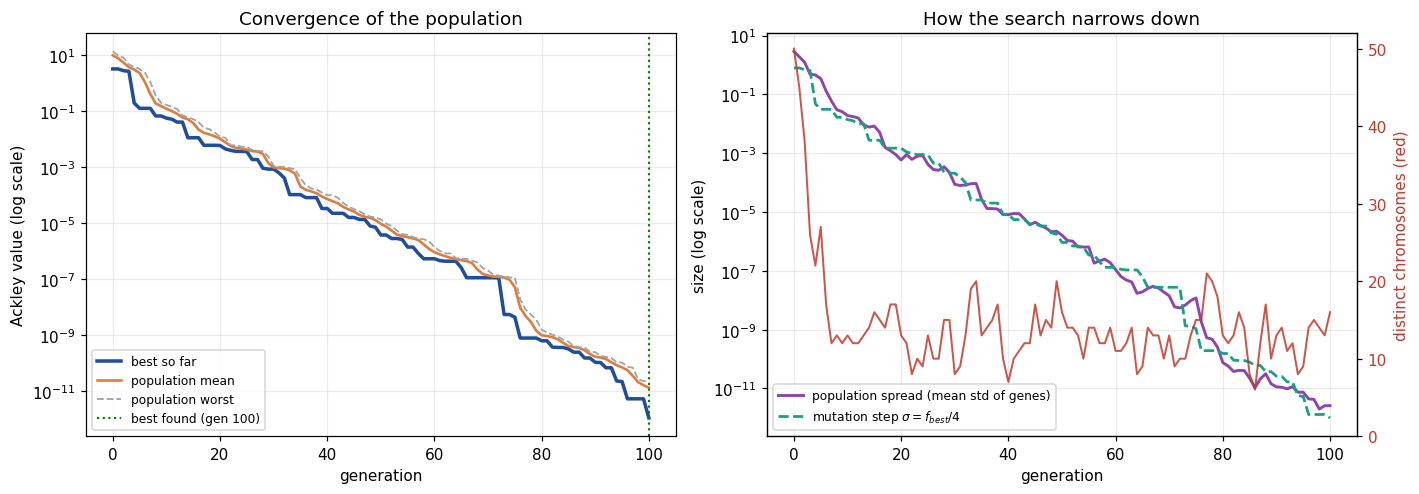

distinct chromosomes : 50 at generation 0, median 13 over the second half, 16 at the end
generations where all 50 were identical : 0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
floor = 1e-16

ax = axes[0]
ax.semilogy(history["generation"], np.maximum(history["best"], floor),
            color="#1f4e9c", linewidth=2.3, label="best so far")
ax.semilogy(history["generation"], np.maximum(history["mean"], floor),
            color="#e07b39", linewidth=1.7, label="population mean")
ax.semilogy(history["generation"], np.maximum(history["worst"], floor),
            color="#9aa5b1", linewidth=1.2, linestyle="--", label="population worst")
ax.axvline(result["best_generation"], color="green", linestyle=":", linewidth=1.4,
           label=f"best found (gen {result['best_generation']})")
ax.set_xlabel("generation")
ax.set_ylabel("Ackley value (log scale)")
ax.set_title("Convergence of the population")
ax.legend(fontsize=8)

ax = axes[1]
spread = np.where(history["spread"] > 0, history["spread"], np.nan)
ax.semilogy(history["generation"], spread,
            color="#8e44ad", linewidth=1.9, label="population spread (mean std of genes)")
ax.semilogy(history["generation"], history["sigma"],
            color="#16a085", linewidth=1.8, linestyle="--",
            label=r"mutation step $\sigma = f_{best}/4$")
ax.set_xlabel("generation")
ax.set_ylabel("size (log scale)")
ax.set_title("How the search narrows down")
ax.legend(fontsize=8, loc="lower left")

twin = ax.twinx()
twin.plot(history["generation"], history["distinct"],
          color="#c0392b", linewidth=1.3, alpha=0.85)
twin.set_ylabel("distinct chromosomes (red)", color="#c0392b")
twin.tick_params(axis="y", labelcolor="#c0392b")
twin.set_ylim(0, SETTINGS.population_size + 2)
twin.grid(False)

plt.tight_layout()
plt.show()

distinct = np.asarray(history["distinct"])
half = len(distinct) // 2
print("distinct chromosomes : %d at generation 0, median %.0f over the second half, %d at the end"
      % (distinct[0], np.median(distinct[half:]), distinct[-1]))
print("generations where all 50 were identical : %d" % int((distinct == 1).sum()))

## 20. Print selected generations

- Show the first few generations and then every tenth generation.
- Include objective values, best coordinates, mutation step, and diversity.
- The best column should never increase because the elite is preserved.

In [20]:
rows = [g for g in history["generation"] if g <= 5 or g % 10 == 0]

print(" gen        best f        mean f       worst f      best x1       best x2      sigma   distinct")
print(" " + "-" * 100)
for g in rows:
    i = int(np.where(history["generation"] == g)[0][0])
    print(" %3d   %12.6e  %12.6e  %12.4e  %+11.3e  %+11.3e  %9.2e   %3d"
          % (g, history["best"][i], history["mean"][i], history["worst"][i],
             history["best_x1"][i], history["best_x2"][i],
             history["sigma"][i], history["distinct"][i]))
print(" " + "-" * 100)
print(" The best column never increases, because the elite is always kept.")

 gen        best f        mean f       worst f      best x1       best x2      sigma   distinct
 ----------------------------------------------------------------------------------------------------
   0   3.188874e+00  9.755876e+00    1.3385e+01   +4.548e-02   +5.350e-01   7.97e-01    50
   1   3.188874e+00  7.671509e+00    9.7171e+00   +4.548e-02   +5.350e-01   7.97e-01    45
   2   2.763082e+00  5.349901e+00    8.0686e+00   +7.772e-02   +9.818e-01   6.91e-01    38
   3   2.619472e+00  3.677568e+00    4.5585e+00   -3.227e-01   +1.489e-01   6.55e-01    26
   4   1.913231e-01  3.039920e+00    3.7560e+00   +4.548e-02   -1.227e-02   4.78e-02    22
   5   1.247882e-01  2.278186e+00    3.1889e+00   -3.127e-02   -1.227e-02   3.12e-02    27
  10   5.566617e-02  1.205450e-01    1.6658e-01   +1.561e-02   +6.673e-03   1.39e-02    13
  20   5.869479e-03  1.027970e-02    1.1912e-02   +5.821e-04   +1.951e-03   1.47e-03    13
  30   8.381199e-04  9.600733e-04    1.0981e-03   -7.124e-05   +2.868e-04 

## 21. Plot the best-solution path

- Keep only generations that improved the best-so-far solution.
- Plot those points on a wide view and a zoomed view near the origin.
- The path shows exploration first and fine adjustment later.

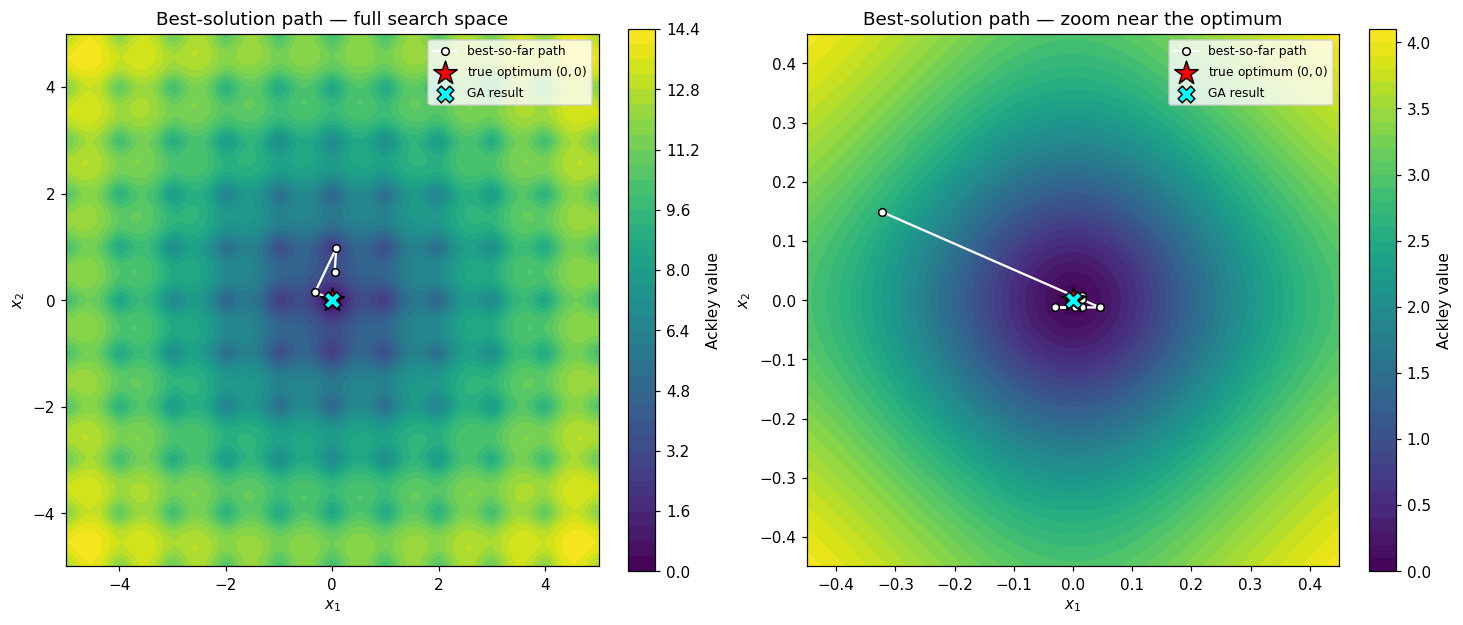

The best solution was improved 56 times during the run.


In [21]:
path = np.column_stack([history["best_x1"], history["best_x2"]])
changed = np.r_[True, np.any(np.diff(path, axis=0) != 0, axis=1)]
improvements = path[changed]

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.8))

for ax, limit, label in [(axes[0], 5.0, "full search space"), (axes[1], 0.45, "zoom near the optimum")]:
    g = np.linspace(-limit, limit, 400)
    A, B = np.meshgrid(g, g)
    filled = ax.contourf(A, B, ackley(np.stack([A, B], axis=-1)), levels=45, cmap="viridis")
    fig.colorbar(filled, ax=ax, fraction=0.046, label="Ackley value")

    inside = np.all(np.abs(improvements) <= limit, axis=1)
    ax.plot(improvements[inside, 0], improvements[inside, 1], "o-",
            color="white", markeredgecolor="black", markersize=5,
            linewidth=1.5, label="best-so-far path")
    ax.scatter(0, 0, marker="*", s=260, color="red", edgecolor="black",
               zorder=6, label="true optimum $(0,0)$")
    ax.scatter(best_x1, best_x2, marker="X", s=120, color="cyan",
               edgecolor="black", zorder=6, label="GA result")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"Best-solution path — {label}")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("The best solution was improved %d times during the run." % (len(improvements) - 1))

## 22. Plot population snapshots

- Display all 50 chromosomes at six stages of the run.
- Use the same landscape and limits so the panels are comparable.
- The sequence shows the population moving toward the central valley.

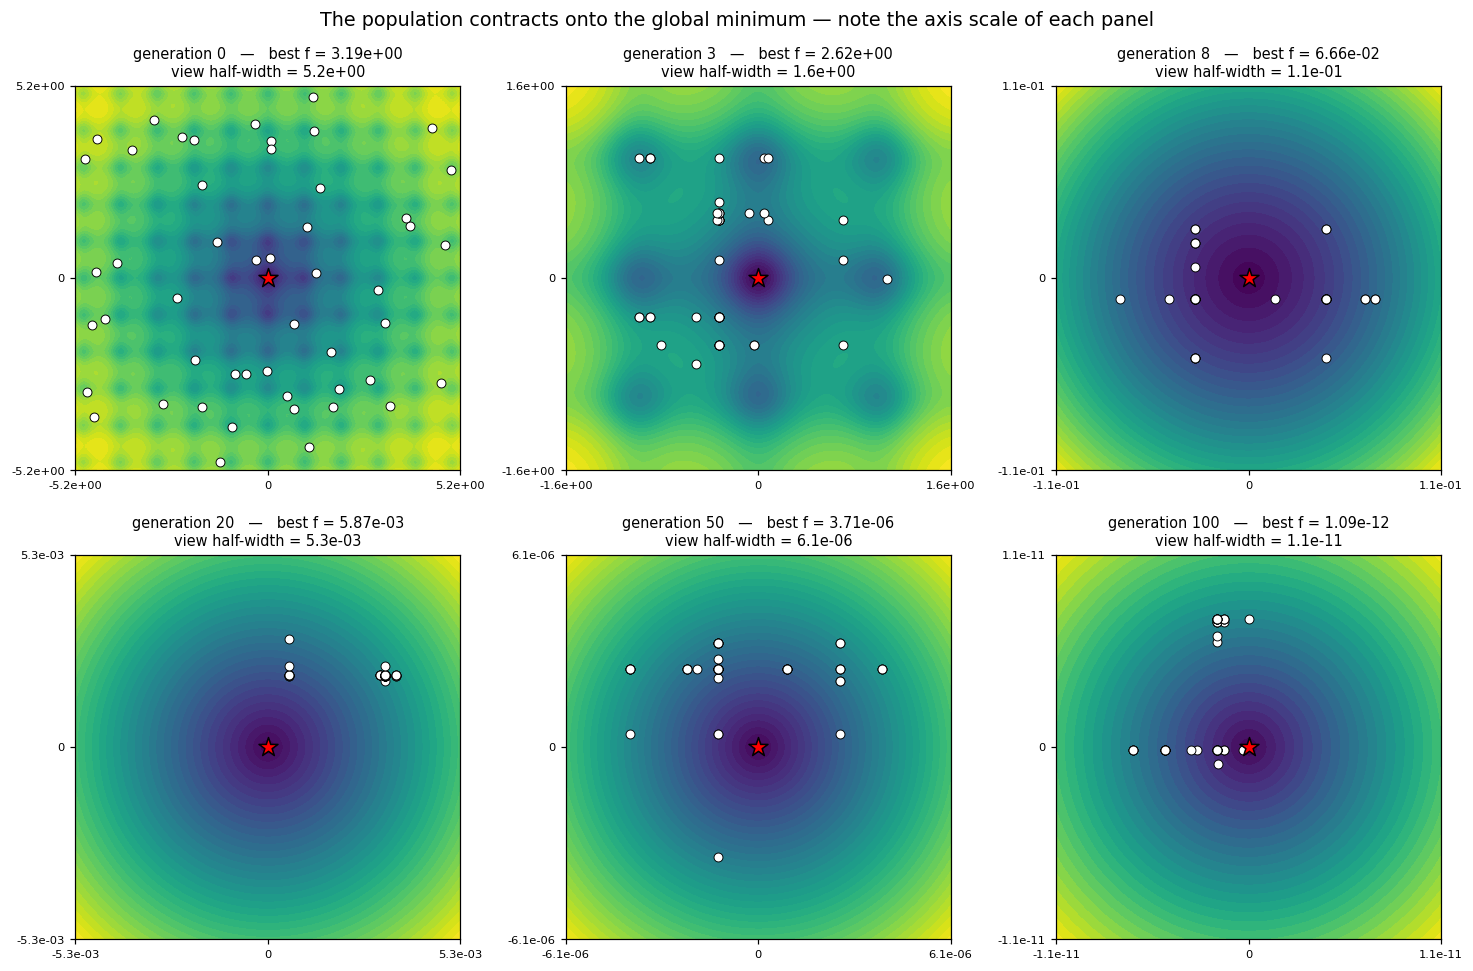

 gen   distinct   spread (mean std of genes)
    0       50     2.889094e+00
    3       26     4.885781e-01
    8       13     3.007080e-02
   20       13     5.898909e-04
   50       16     1.635479e-06
  100       16     2.601965e-12


In [22]:
available = [g for g in SNAPSHOT_GENERATIONS if g in result["snapshots"]]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.0))

for ax, generation in zip(axes.ravel(), available):
    snapshot = result["snapshots"][generation]

    limit = max(min(1.5 * np.abs(snapshot).max(), 5.2), 1e-13)
    g = np.linspace(-limit, limit, 200)
    A, B = np.meshgrid(g, g)
    ax.contourf(A, B, ackley(np.stack([A, B], axis=-1)), levels=40, cmap="viridis")

    ax.scatter(snapshot[:, 0], snapshot[:, 1], s=34, color="white",
               edgecolor="black", linewidth=0.6, zorder=4)
    ax.scatter(0, 0, marker="*", s=170, color="red", edgecolor="black", zorder=5)
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit); ax.set_aspect("equal")
    ax.set_title("generation %d   —   best f = %.2e\nview half-width = %.1e"
                 % (generation, ackley(snapshot).min(), limit), fontsize=9.5)
    ax.set_xticks([-limit, 0, limit])
    ax.set_xticklabels([f"{-limit:.1e}", "0", f"{limit:.1e}"], fontsize=7.5)
    ax.set_yticks([-limit, 0, limit])
    ax.set_yticklabels([f"{-limit:.1e}", "0", f"{limit:.1e}"], fontsize=7.5)

for ax in axes.ravel()[len(available):]:
    ax.axis("off")

fig.suptitle("The population contracts onto the global minimum — note the axis scale of each panel",
             fontsize=12.5)
plt.tight_layout()
plt.show()

print(" gen   distinct   spread (mean std of genes)")
for generation in available:
    snapshot = result["snapshots"][generation]
    print("  %3d   %6d     %.6e"
          % (generation, len(np.unique(snapshot, axis=0)), np.mean(np.std(snapshot, axis=0))))

## 23. Compare early and later roulette wheels

- Recalculate selection probabilities for generation 0 and a later snapshot.
- Plot both wheels using the same display rule.
- This shows how selection changes as objective values become closer.

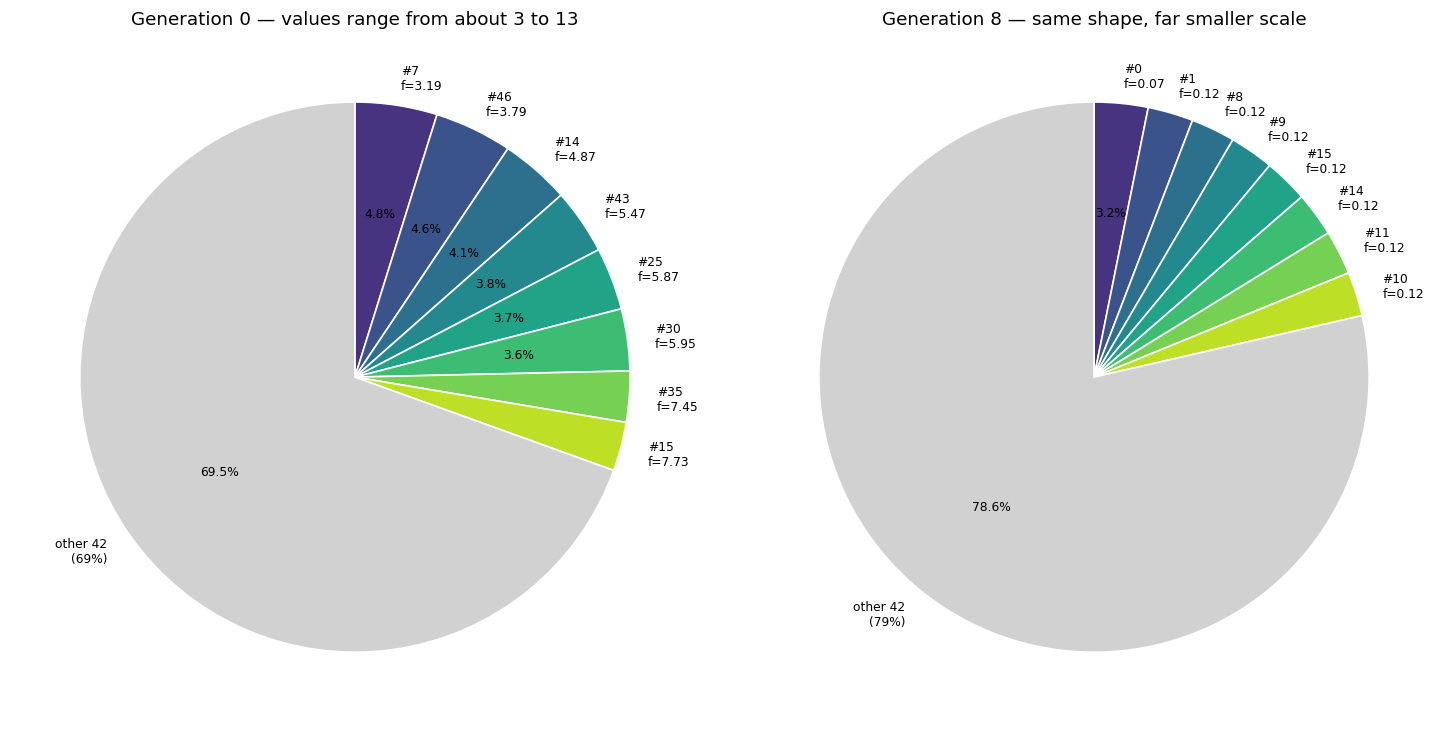

In [23]:
mid_generation = [g for g in available if g >= 8][0]
mid_values = ackley(result["snapshots"][mid_generation])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.6))
p_early = plot_roulette_pie(initial_values, ax=axes[0], n_labelled=8,
                            title="Generation 0 — values range from about 3 to 13")
p_mid = plot_roulette_pie(mid_values, ax=axes[1], n_labelled=8,
                          title=f"Generation {mid_generation} — same shape, far smaller scale")
plt.tight_layout()
plt.show()

## 24. Compare fitness transformations

- Measure the largest roulette slice under windowing and inverse fitness.
- Print the ratio between the largest and smallest selection probabilities.
- The table shows how selection pressure changes during the run.

In [24]:
print(" gen   distinct   best f        worst f      largest slice   ratio max/min")
print("                                                  windowing | inverse")
print(" " + "-" * 78)
for generation in available:
    snapshot = result["snapshots"][generation]
    v = ackley(snapshot)
    pw = selection_probabilities(v, "windowing")
    pi = selection_probabilities(v, "inverse")
    print(" %3d   %6d   %11.4e  %11.4e   %8.2f %%   %8.2f | %7.2f"
          % (generation, len(np.unique(snapshot, axis=0)), v.min(), v.max(),
             100 * pw.max(), pw.max() / pw.min(), pi.max() / pi.min()))
print(" " + "-" * 78)

 gen   distinct   best f        worst f      largest slice   ratio max/min
                                                  windowing | inverse
 ------------------------------------------------------------------------------
   0       50    3.1889e+00   1.3385e+01       4.83 %      11.00 |    3.43
   3       26    2.6195e+00   4.5585e+00       3.97 %      11.00 |    1.54
   8       13    6.6625e-02   3.6341e-01       3.16 %      11.00 |    1.28
  20       13    5.8695e-03   1.1912e-02       5.94 %      11.00 |    1.01
  50       16    3.7131e-06   1.3358e-05       4.21 %      11.00 |    1.00
 100       16    1.0876e-12   2.1523e-11       4.07 %       7.71 |    1.00
 ------------------------------------------------------------------------------


## 25. Test the two proposed fixes

- Run four combinations of mutation-step rule and duplicate limit.
- Use the same 40 seeds for a fair comparison.
- Report median error, worst error, correct-valley count, and diversity.

This cell runs 160 GA experiments, so it may take a little time.

In [25]:
def compare_versions(label, settings, n_runs=40):
    values, distances, distinct = [], [], []
    for seed in range(n_runs):
        one = run_ga(replace(settings, seed=seed), verbose=False)
        values.append(one["best_value"])
        distances.append(float(np.linalg.norm(one["best_solution"])))
        d = one["history"]["distinct"]
        distinct.append(float(np.median(d[len(d) // 2:])))
    values, distances = np.asarray(values), np.asarray(distances)
    return {
        "label": label,
        "median": np.median(values),
        "worst": values.max(),
        "basin": float((distances < 0.5).mean()),   # ended in the correct valley?
        "distinct": np.median(distinct),
    }


rows = [
    compare_versions("clock sigma  |  no cap   (v1)",
                     replace(SETTINGS, sigma_kind="schedule", max_copies=0)),
    compare_versions("clock sigma  |  cap 15",
                     replace(SETTINGS, sigma_kind="schedule")),
    compare_versions("adaptive     |  no cap",
                     replace(SETTINGS, max_copies=0)),
    compare_versions("adaptive     |  cap 15  (final)", SETTINGS),
]

print(" mutation step | duplicates       median f      worst f     correct valley   distinct")
print(" " + "-" * 84)
for r in rows:
    print(" %-32s %11.3e  %11.3e      %5.0f %%       %5.0f"
          % (r["label"], r["median"], r["worst"], 100 * r["basin"], r["distinct"]))
print(" " + "-" * 84)
print(" 'correct valley' = the run ended within 0.5 of (0,0) rather than on a ring of local minima.")
print(" 'distinct'       = median number of different chromosomes in the second half of the run.")

 mutation step | duplicates       median f      worst f     correct valley   distinct
 ------------------------------------------------------------------------------------
 clock sigma  |  no cap   (v1)      5.516e-09    2.580e+00         98 %           3
 clock sigma  |  cap 15             6.761e-09    2.580e+00         98 %           9
 adaptive     |  no cap             4.996e-13    2.306e-11        100 %           8
 adaptive     |  cap 15  (final)    1.636e-12    3.137e-11        100 %          13
 ------------------------------------------------------------------------------------
 'correct valley' = the run ended within 0.5 of (0,0) rather than on a ring of local minima.
 'distinct'       = median number of different chromosomes in the second half of the run.


## 26. Reliability over 40 random seeds

- Run the final GA with seeds 0 through 39.
- Count a run as precise when its final value is below $10^{-6}$.
- Summarize the best, median, worst, distance, and generation statistics.

In [26]:
N_RUNS = 40
run_values, run_solutions, run_generations, run_best_generations = [], [], [], []

for seed in range(N_RUNS):
    one = run_ga(replace(SETTINGS, seed=seed), verbose=False)
    run_values.append(one["best_value"])
    run_solutions.append(one["best_solution"])
    run_generations.append(one["generations_run"])
    run_best_generations.append(one["best_generation"])

run_values = np.asarray(run_values)
run_solutions = np.asarray(run_solutions)
run_distances = np.linalg.norm(run_solutions, axis=1)
in_valley = run_distances < 0.5
precise = run_values < 1e-6

print("Summary over %d independent runs" % N_RUNS)
print("-" * 58)
print(" best  f found            : %.6e" % run_values.min())
print(" median f found           : %.6e" % np.median(run_values))
print(" worst f found            : %.6e" % run_values.max())
print(" ended in the correct valley : %d / %d   (%.0f %%)"
      % (in_valley.sum(), N_RUNS, 100 * in_valley.mean()))
print(" reached f < 1e-6            : %d / %d   (%.0f %%)"
      % (precise.sum(), N_RUNS, 100 * precise.mean()))
print(" median distance to (0,0) : %.3e" % np.median(run_distances))
print(" mean generations run     : %.1f" % np.mean(run_generations))
print(" mean generation of best  : %.1f" % np.mean(run_best_generations))
print("-" * 58)

if (~precise).any():
    print(" runs that did not reach 1e-6:")
    for i in np.where(~precise)[0]:
        print("   seed %2d :  f = %.3e   at (%+.4f, %+.4f)"
              % (i, run_values[i], run_solutions[i, 0], run_solutions[i, 1]))
else:
    print(" Every run reached the global minimum to better than 1e-6.")

Summary over 40 independent runs
----------------------------------------------------------
 best  f found            : 1.105782e-13
 median f found           : 1.636469e-12
 worst f found            : 3.137091e-11
 ended in the correct valley : 40 / 40   (100 %)
 reached f < 1e-6            : 40 / 40   (100 %)
 median distance to (0,0) : 5.782e-13
 mean generations run     : 96.1
 mean generation of best  : 95.1
----------------------------------------------------------
 Every run reached the global minimum to better than 1e-6.


## 27. Plot the reliability results

- The bar chart shows the final value from each seed on a log scale.
- The contour plot shows where all 40 final solutions finished.
- The dashed line marks the chosen success threshold, $10^{-6}$.

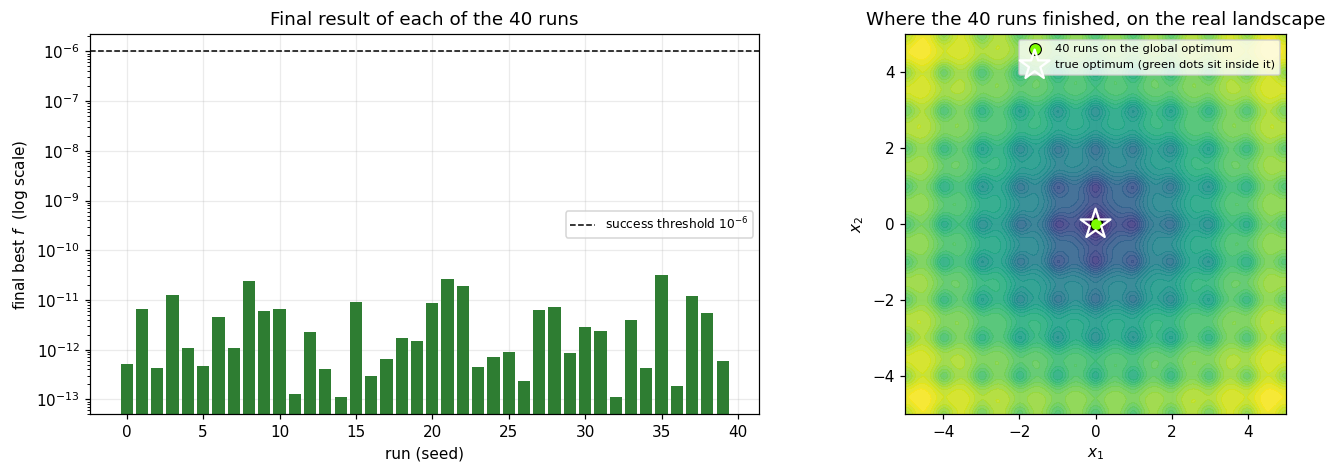

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))

ax = axes[0]
ax.bar(np.arange(N_RUNS), np.maximum(run_values, 1e-18),
       color=["#2e7d32" if p else "#c62828" for p in precise])
ax.set_yscale("log")
ax.axhline(1e-6, color="black", linestyle="--", linewidth=1.0, label="success threshold $10^{-6}$")
ax.set_xlabel("run (seed)")
ax.set_ylabel("final best $f$  (log scale)")
ax.set_title("Final result of each of the %d runs" % N_RUNS)
ax.legend(fontsize=8)

ax = axes[1]
ax.contourf(X1, X2, Z, levels=45, cmap="viridis", alpha=0.9)
ax.scatter(run_solutions[in_valley, 0], run_solutions[in_valley, 1], s=60, color="#7CFC00",
           edgecolor="black", linewidth=0.7, zorder=4,
           label="%d runs on the global optimum" % in_valley.sum())
if (~in_valley).any():
    ax.scatter(run_solutions[~in_valley, 0], run_solutions[~in_valley, 1], s=130,
               color="#ff2d2d", marker="X", edgecolor="black", linewidth=0.9, zorder=5,
               label="%d trapped run(s)" % (~in_valley).sum())
ax.scatter(0, 0, marker="*", s=420, facecolors="none", edgecolors="white", linewidths=1.5,
           zorder=6, label="true optimum (green dots sit inside it)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
ax.set_title("Where the %d runs finished, on the real landscape" % N_RUNS)
ax.legend(fontsize=7.5, loc="upper right")

plt.tight_layout()
plt.show()

## 28. Ablation study

- Change one GA component at a time and run each version with 15 seeds.
- Compare median result, worst result, and success rate.
- This identifies which operators have the largest effect on this experiment.

This cell runs 150 GA experiments and may take a little time.

In [28]:
def evaluate_variant(label, changes, n_runs=15):
    values = np.asarray([run_ga(replace(SETTINGS, seed=s, **changes), verbose=False)["best_value"]
                         for s in range(n_runs)])
    return {"label": label, "median": np.median(values), "worst": values.max(),
            "success": float((values < 1e-6).mean())}


variants = [
    evaluate_variant("full GA as specified", {}),
    evaluate_variant("clock-based sigma schedule", {"sigma_kind": "schedule"}),
    evaluate_variant("fixed sigma = 0.1", {"sigma_kind": "fixed", "sigma_start": 0.1}),
    evaluate_variant("uniform mutation instead of Gaussian", {"mutation_kind": "uniform"}),
    evaluate_variant("no duplicate cap", {"max_copies": 0}),
    evaluate_variant("inverse fitness 1/(1+f)", {"fitness_kind": "inverse"}),
    evaluate_variant("survivors from offspring only", {"survivor_kind": "offspring_only"}),
    evaluate_variant("no crossover (Pc = 0)", {"pc": 0.0}),
    evaluate_variant("no mutation (Pm = 0)", {"pm": 0.0}),
    evaluate_variant("no elitism, offspring-only survivors",
                     {"n_elites": 0, "survivor_kind": "offspring_only"}),
]

print(" variant                                  median f      worst f     success rate")
print(" " + "-" * 76)
for v in variants:
    print(" %-38s %11.3e  %11.3e   %9.0f %%"
          % (v["label"], v["median"], v["worst"], 100 * v["success"]))
print(" " + "-" * 76)

 variant                                  median f      worst f     success rate
 ----------------------------------------------------------------------------
 full GA as specified                     1.088e-12    2.449e-11         100 %
 clock-based sigma schedule               6.415e-09    1.721e-08         100 %
 fixed sigma = 0.1                        3.655e-03    1.188e-02           0 %
 uniform mutation instead of Gaussian     1.682e-01    5.887e-01           0 %
 no duplicate cap                         3.948e-13    3.656e-12         100 %
 inverse fitness 1/(1+f)                  3.001e-10    6.198e-08         100 %
 survivors from offspring only            5.100e-08    2.180e-07         100 %
 no crossover (Pc = 0)                    5.469e-10    8.337e-09         100 %
 no mutation (Pm = 0)                     1.172e+00    2.531e+00           0 %
 no elitism, offspring-only survivors     3.493e-05    5.653e-03           0 %
 --------------------------------------------------

## 29. Same-budget random-search baseline

- Give random search the same 5,050-point budget as the main GA run.
- Use the same seed for a reproducible comparison.
- Compare the smallest random-search value with the GA result.

In [29]:
budget = SETTINGS.population_size * (result["generations_run"] + 1)
baseline_rng = np.random.default_rng(SETTINGS.seed)
random_points = baseline_rng.uniform(SETTINGS.lower, SETTINGS.upper, size=(budget, 2))
random_best = ackley(random_points).min()

print("function evaluations allowed to both methods : %d" % budget)
print()
print("pure random search  : f = %.6e" % random_best)
print("genetic algorithm   : f = %.6e" % best_f)
print()
print("The GA is better by a factor of about %.3g." % (random_best / max(best_f, 1e-300)))
print("Both looked at the same number of points; the GA chose where to look next")
print("using what it had already learned.")

function evaluations allowed to both methods : 5050

pure random search  : f = 7.693070e-01
genetic algorithm   : f = 1.087574e-12

The GA is better by a factor of about 7.07e+11.
Both looked at the same number of points; the GA chose where to look next
using what it had already learned.


## 30. Correctness checks

- Confirm the objective, population shape, bounds, elitism, and duplicate limit.
- Check that roulette probabilities are positive and sum to one.
- Rerun the seeded GA to confirm that the result is reproducible.

In [30]:
assert abs(ackley([0.0, 0.0])) < 1e-12, "f(0,0) must be 0"

assert result["population"].shape == (SETTINGS.population_size, SETTINGS.n_genes), \
    "population must stay 50 x 2"
assert np.all(result["population"] >= SETTINGS.lower), "a gene fell below -5"
assert np.all(result["population"] <= SETTINGS.upper), "a gene rose above +5"
assert np.all(np.isfinite(result["values"])), "an objective value is not finite"

assert np.all(np.diff(history["best"]) <= 1e-15), "elitism broken: best-so-far got worse"
assert np.isclose(ackley(result["best_solution"]), result["best_value"]), \
    "reported best value does not match the reported chromosome"
assert result["best_value"] <= history["best"][0], "no improvement over generation 0"

counts = np.unique(result["population"], axis=0, return_counts=True)[1]
assert counts.max() <= SETTINGS.max_copies, "the duplicate cap was exceeded"

probabilities_check = selection_probabilities(result["values"], SETTINGS.fitness_kind)
assert np.isclose(probabilities_check.sum(), 1.0), "selection probabilities must sum to 1"
assert np.all(probabilities_check > 0), "every chromosome must keep a non-zero chance"

assert np.isclose(run_ga(SETTINGS, verbose=False)["best_value"], result["best_value"]), \
    "the seeded run is not reproducible"

print("All correctness checks passed.")
print("  - f(0,0) = 0")
print("  - population stayed 50 x 2 and inside [-5, +5]")
print("  - best-so-far never got worse (elitism holds)")
print("  - no chromosome exceeded %d of the 50 seats" % SETTINGS.max_copies)
print("  - selection probabilities sum to 1 and none is zero")
print("  - the seeded run reproduces exactly")

All correctness checks passed.
  - f(0,0) = 0
  - population stayed 50 x 2 and inside [-5, +5]
  - best-so-far never got worse (elitism holds)
  - no chromosome exceeded 15 of the 50 seats
  - selection probabilities sum to 1 and none is zero
  - the seeded run reproduces exactly


## Result

For seed 7, the GA returns a point extremely close to $(0,0)$ with an Ackley value near $10^{-12}$. All 40 tested seeds finish below the chosen success threshold of $10^{-6}$.

The experiment shows the separate roles of selection, crossover, mutation, adaptive step size, elitism, and diversity control.